In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, factorial

In [2]:
#Defining parameters

MAX_CARS = 20
MAX_MOVE = 5
RENT_REWARD = 10
MOVE_COST = 2
gamma = 0.9
theta = 1e-4

lam_rent1 = 3
lam_rent2 = 4
lam_ret1 = 3
lam_ret2 = 2

In [3]:
#Poisson cache

poisson_cache = {}

def poisson(lam, n):
    if (lam,n) not in poisson_cache:
        poisson_cache[(lam,n)] = exp(-lam) * lam**n / factorial(n)
    return poisson_cache[(lam,n)]

def poisson_probs(lam):
    probs = [poisson(lam,n) for n in range(10)]
    probs.append(1 - sum(probs))
    return probs

P = {
    lam_rent1: poisson_probs(lam_rent1),
    lam_rent2: poisson_probs(lam_rent2),
    lam_ret1: poisson_probs(lam_ret1),
    lam_ret2: poisson_probs(lam_ret2)
}

In [8]:
#Expected return

def expected_return(i, j, a, V):

    # apply action
    i = min(MAX_CARS, max(0, i - a))
    j = min(MAX_CARS, max(0, j + a))

    total = -MOVE_COST * abs(a)

    value = 0.0

    for r1 in range(7):
        for r2 in range(7):
            p_rent = P[lam_rent1][r1] * P[lam_rent2][r2]

            real_r1 = min(i, r1)
            real_r2 = min(j, r2)

            reward = RENT_REWARD * (real_r1 + real_r2)

            i2 = i - real_r1
            j2 = j - real_r2

            for b1 in range(7):
                for b2 in range(7):
                    p = p_rent * P[lam_ret1][b1] * P[lam_ret2][b2]

                    ni = min(MAX_CARS, i2 + b1)
                    nj = min(MAX_CARS, j2 + b2)

                    value += p * (reward + gamma * V[ni][nj])

    return total + value

In [5]:
V = np.zeros((21,21))
policy = np.zeros((21,21), dtype=int)

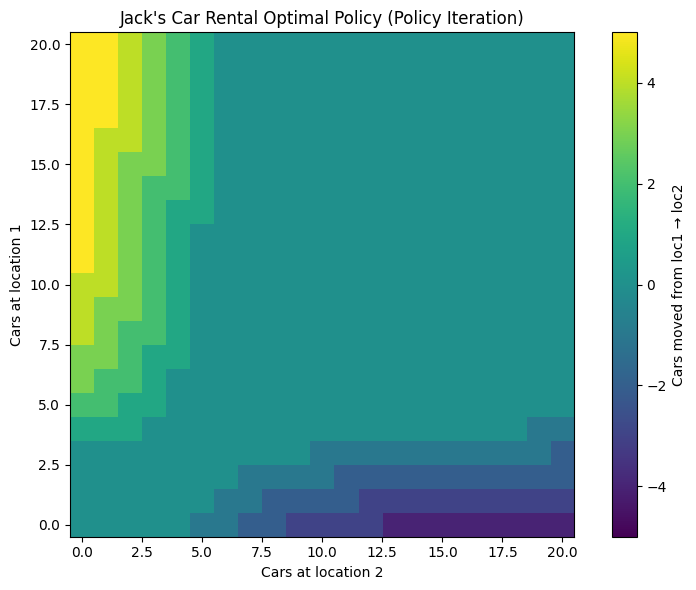

In [10]:
while True:
    while True:
        delta = 0
        newV = V.copy()

        for i in range(21):
            for j in range(21):
                a = policy[i,j]
                newV[i,j] = expected_return(i,j,a,V)
                delta = max(delta, abs(newV[i,j] - V[i,j]))

        V = newV
        if delta < theta:
            break

    policy_stable = True

    for i in range(21):
        for j in range(21):

            old_action = policy[i,j]
            best_val = -float("inf")
            best_action = old_action

            for a in range(-MAX_MOVE, MAX_MOVE+1):
                if a <= i and -a <= j:
                    val = expected_return(i,j,a,V)
                    if val > best_val:
                        best_val = val
                        best_action = a

            policy[i,j] = best_action
            if best_action != old_action:
                policy_stable = False

    if policy_stable:
        break

plt.figure(figsize=(8,6))
im = plt.imshow(policy, origin="lower",
                cmap="viridis", vmin=-5, vmax=5)

plt.colorbar(im, label="Cars moved from loc1 → loc2")
plt.xlabel("Cars at location 2")
plt.ylabel("Cars at location 1")
plt.title("Jack's Car Rental Optimal Policy (Policy Iteration)")
plt.tight_layout()
plt.show()